# 08 — Blinded ABCD expected-limit machinery

This notebook builds an expected-only four-region ABCD likelihood from the outputs used in notebook 06.

- SR Data A is never extracted, displayed, or used.
- SR Data B/C/D constrain the factorized background model.
- Signal yields in A/B/C/D are included, so control-region contamination is part of the fit.
- The result is an expected limit on the nominal signal strength $\mu$; it is not yet a cross-section limit.
- The ABCD non-closure uncertainty is scanned as a scenario, not claimed as a final prescription.


In [1]:
import gc
import json
import os
import re
import sys
import warnings
from pathlib import Path

import coffea.util
import matplotlib.pyplot as plt
import numpy as np
if int(np.__version__.split(".")[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault("numpy._core", _numpy_core)
    sys.modules.setdefault("numpy._core.numeric", _numpy_numeric)
import pandas as pd
import pyhf

pyhf.set_backend("numpy")
print(f"pyhf {pyhf.__version__}")


pyhf 0.7.6


## 1. Configuration and blinding contract

`ALLOW_SR_DATA_A` is fixed to `False` in this notebook. The loaded 2D payload contains the blinded quadrant, but Data extraction returns only B/C/D and no A yield is materialized.

In [2]:
ALLOW_SR_DATA_A = False
assert ALLOW_SR_DATA_A is False, "Notebook 08 is expected-only and must remain blinded"

BASE = Path.cwd()
if BASE.name != "ABCD_Study":
    candidate = BASE / "sidm" / "studies" / "ABCD_Study"
    if candidate.exists():
        BASE = candidate

DATA_DIR = BASE / "test_ABCD_data_full_merge_v1"
SIGNAL_DIR = BASE / "test_ABCD_signal_full_merge_v1"
RESULT_DIR = BASE / "expected_limit_outputs"
REPOSITORY_ROOT = BASE.parents[2]
if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))

CHANNEL_CONFIGS = {
    "2mu2e": {"hist": "mulj_egmlj_iso", "channel": "test_SR_2mu2e", "cuts": (0.25, 0.10)},
    "4mu": {"hist": "mulj_mulj_iso", "channel": "test_SR_4mu", "cuts": (0.25, 0.25)},
}
KAPPA_RELATIVE_UNCERTAINTIES = (0.0, 0.2, 0.5, 1.0)
RUN_FULL_SCAN = False
DEVELOPMENT_POINTS_PER_TOPOLOGY = 2
REGIONS = ("A", "B", "C", "D")
SIGNAL_LOW_STAT_NEFF = 10.0
SIGNAL_PATTERN = re.compile(
    r"^(?P<label>2Mu2E|4Mu)_(?P<mA>[0-9p]+)GeV_(?P<mZd>[0-9p]+)GeV_(?P<ctau>[0-9p]+)mm$"
)

for path in (DATA_DIR, SIGNAL_DIR):
    if not path.is_dir():
        raise FileNotFoundError(path)
print("Data files:", len(list(DATA_DIR.glob("DoubleMuon_*.coffea"))))
print("Signal files:", len(list(SIGNAL_DIR.glob("*.coffea"))))


Data files: 68
Signal files: 120


## 2. Lightweight payload loading and ABCD extraction

In [3]:
def load_sample(path, required_hist):
    loaded = coffea.util.load(path)
    payloads = loaded.get("out", loaded)
    sample = path.stem
    payload = payloads[sample]
    return payload["hists"][required_hist]


def select_channel(histogram, channel):
    if "channel" in histogram.axes.name:
        return histogram[{"channel": channel}]
    return histogram


def add_histograms(histograms):
    histograms = list(histograms)
    if not histograms:
        raise ValueError("No histograms to add")
    total = histograms[0].copy()
    for histogram in histograms[1:]:
        total = total + histogram
    return total


def values_variances(histogram):
    """Match notebook 06: exclude underflow and fold overflow into the final visible bin."""
    values = np.asarray(histogram.values(flow=True), dtype=float).copy()
    variances = histogram.variances(flow=True)
    variances = np.clip(values, 0, None) if variances is None else np.asarray(variances, dtype=float).copy()
    values[-2, :] += values[-1, :]
    variances[-2, :] += variances[-1, :]
    values, variances = values[:-1, :], variances[:-1, :]
    values[:, -2] += values[:, -1]
    variances[:, -2] += variances[:, -1]
    values = values[:, :-1]
    variances = variances[:, :-1]
    return values[1:, 1:], variances[1:, 1:]


def abcd_masks(histogram, cuts):
    x = np.asarray(histogram.axes[0].centers)[:, None]
    y = np.asarray(histogram.axes[1].centers)[None, :]
    xcut, ycut = cuts
    return {
        "A": (x < xcut) & (y < ycut),
        "B": (x >= xcut) & (y < ycut),
        "C": (x < xcut) & (y >= ycut),
        "D": (x >= xcut) & (y >= ycut),
    }


def region_stats(histogram, cuts, regions=REGIONS):
    values, variances = values_variances(histogram)
    masks = abcd_masks(histogram, cuts)
    result = {}
    for region in regions:
        value = float(values[masks[region]].sum())
        variance = float(np.clip(variances[masks[region]].sum(), 0, None))
        result[region] = {
            "yield": value,
            "variance": variance,
            "error": np.sqrt(variance),
            "neff": value**2 / variance if variance > 0 else np.nan,
        }
    return result


def parse_signal(sample):
    match = SIGNAL_PATTERN.match(sample)
    if match is None:
        raise ValueError(f"Unrecognized signal name: {sample}")
    fields = match.groupdict()
    number = lambda token: float(token.replace("p", "."))
    return {
        "topology": "2mu2e" if fields["label"] == "2Mu2E" else "4mu",
        "mA_GeV": number(fields["mA"]),
        "mZd_GeV": number(fields["mZd"]),
        "ctau_mm": number(fields["ctau"]),
    }


In [4]:
# Data A is not returned by construction.
data_sidebands = {}
for topology, config in CHANNEL_CONFIGS.items():
    pieces = []
    for path in sorted(DATA_DIR.glob("DoubleMuon_*.coffea")):
        pieces.append(select_channel(load_sample(path, config["hist"]), config["channel"]))
    total = add_histograms(pieces)
    data_sidebands[topology] = region_stats(total, config["cuts"], regions=("B", "C", "D"))
    del pieces, total
    gc.collect()

sideband_table = pd.DataFrame([
    {"topology": topology, **{region: stats[region]["yield"] for region in ("B", "C", "D")}}
    for topology, stats in data_sidebands.items()
])
sideband_table["A_raw_prediction"] = sideband_table.B * sideband_table.C / sideband_table.D
display(sideband_table)
assert np.all(sideband_table[["B", "C", "D"]].to_numpy() > 0), "ABCD fit requires positive sidebands"


,topology,B,C,D,A_raw_prediction
0,2mu2e,134.0,167.0,305.0,73.370492
1,4mu,18.0,177.0,36.0,88.500000


## 3. Four-region factorized likelihood

The background model is

$$b_D=\nu,\quad b_B=\nu\tau_x,\quad b_C=\nu\tau_y,\quad b_A=\kappa\nu\tau_x\tau_y.$$

The same signal-strength parameter multiplies the signal in every region. A `normsys` modifier on A represents a positive, log-interpolated non-closure nuisance.

In [5]:
def initial_abcd_parameters(sidebands):
    b, c, d = (sidebands[r]["yield"] for r in ("B", "C", "D"))
    if min(b, c, d) <= 0:
        raise ValueError("B, C and D must all be positive")
    return {"nu": d, "tau_x": b / d, "tau_y": c / d}


def positive_bounds(value):
    return [max(value * 1e-4, 1e-8), max(value * 1e4, 10.0)]


def build_workspace(sidebands, signal, kappa_relative_uncertainty=0.0, include_signal_stat=False):
    initials = initial_abcd_parameters(sidebands)
    channels = []
    for region in REGIONS:
        background_modifiers = [{"name": "nu", "type": "normfactor", "data": None}]
        if region in ("A", "B"):
            background_modifiers.append({"name": "tau_x", "type": "normfactor", "data": None})
        if region in ("A", "C"):
            background_modifiers.append({"name": "tau_y", "type": "normfactor", "data": None})
        if region == "A" and kappa_relative_uncertainty > 0:
            delta = float(kappa_relative_uncertainty)
            background_modifiers.append({
                "name": "kappa_nonclosure",
                "type": "normsys",
                "data": {"lo": max(1.0 - delta, 1e-3), "hi": 1.0 + delta},
            })

        signal_yield = float(signal[region]["yield"])
        signal_error = float(signal[region]["error"])
        if signal_yield < 0:
            raise ValueError(f"Negative signal yield in {region}: {signal_yield}")
        signal_modifiers = [{"name": "mu", "type": "normfactor", "data": None}]
        if include_signal_stat and signal_yield > 0 and signal_error > 0:
            signal_modifiers.append({
                "name": f"signal_stat_{region}", "type": "staterror", "data": [signal_error]
            })

        channels.append({
            "name": region,
            "samples": [
                {"name": "background", "data": [1.0], "modifiers": background_modifiers},
                {"name": "signal", "data": [signal_yield], "modifiers": signal_modifiers},
            ],
        })

    parameters = [
        {"name": "mu", "inits": [1.0], "bounds": [[0.0, 1e4]], "fixed": False},
        {"name": "nu", "inits": [initials["nu"]], "bounds": [positive_bounds(initials["nu"])], "fixed": False},
        {"name": "tau_x", "inits": [initials["tau_x"]], "bounds": [positive_bounds(initials["tau_x"])], "fixed": False},
        {"name": "tau_y", "inits": [initials["tau_y"]], "bounds": [positive_bounds(initials["tau_y"])], "fixed": False},
    ]
    spec = {
        "version": "1.0.0",
        "channels": channels,
        "observations": [{"name": region, "data": [0.0]} for region in REGIONS],
        "measurements": [{
            "name": "ExpectedLimit",
            "config": {"poi": "mu", "parameters": parameters},
        }],
    }
    return pyhf.Workspace(spec)


def background_only_asimov(workspace):
    model = workspace.model(measurement_name="ExpectedLimit")
    pars = np.asarray(model.config.suggested_init(), dtype=float)
    pars[model.config.poi_index] = 0.0
    data = np.asarray(model.expected_data(pars, include_auxdata=True), dtype=float)
    return model, data


def expected_upper_limit(workspace):
    model, data = background_only_asimov(workspace)
    observed_asimov, expected = pyhf.infer.intervals.upper_limits.upper_limit(
        data, model, scan=None, level=0.05
    )
    expected = np.asarray(expected, dtype=float)
    return {
        "asimov_observed_mu95": float(observed_asimov),
        "exp_m2": expected[0], "exp_m1": expected[1], "exp_median": expected[2],
        "exp_p1": expected[3], "exp_p2": expected[4],
    }


## 4. Mandatory toy validation

This test must pass before scanning real signals. With B=40, C=30 and D=20, the fitted background expectation in A must be 60.

In [6]:
toy_sidebands = {r: {"yield": value} for r, value in {"B": 40.0, "C": 30.0, "D": 20.0}.items()}
toy_signal = {
    r: {"yield": value, "error": 0.0}
    for r, value in {"A": 10.0, "B": 1.0, "C": 2.0, "D": 0.5}.items()
}
toy_workspace = build_workspace(toy_sidebands, toy_signal, kappa_relative_uncertainty=0.0)
toy_model, toy_data = background_only_asimov(toy_workspace)
toy_main = toy_data[: toy_model.config.nmaindata]
toy_by_channel = dict(zip(toy_model.config.channels, toy_main))
assert np.isclose(toy_by_channel["A"], 40.0 * 30.0 / 20.0, rtol=1e-10)
toy_limit = expected_upper_limit(toy_workspace)
display(pd.DataFrame([{"A_expected": toy_by_channel["A"], **toy_limit}]))
print("Toy ABCD and expected-limit validation passed")


/usr/local/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/usr/local/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/usr/local/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:493: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])


,A_expected,asimov_observed_mu95,exp_m2,exp_m1,exp_median,exp_p1,exp_p2
0,60.0,4.900368,3.012918,3.812105,4.900368,6.28002,7.893447


Toy ABCD and expected-limit validation passed


## 5. Load signal region yields

Only points with $m_A\geq200$ GeV are retained, matching notebook 06.

In [7]:
signal_inputs = {}
input_rows = []
load_failures = []

for path in sorted(SIGNAL_DIR.glob("*.coffea")):
    sample = path.stem
    try:
        parameters = parse_signal(sample)
        if parameters["mA_GeV"] < 200:
            continue
        config = CHANNEL_CONFIGS[parameters["topology"]]
        histogram = select_channel(load_sample(path, config["hist"]), config["channel"])
        stats = region_stats(histogram, config["cuts"])
        signal_inputs[sample] = {"parameters": parameters, "regions": stats}
        row = {"signal": sample, **parameters}
        for region in REGIONS:
            row[f"signal_{region}"] = stats[region]["yield"]
            row[f"signal_{region}_neff"] = stats[region]["neff"]
        row["low_stat_flag"] = any(
            not np.isfinite(stats[r]["neff"]) or stats[r]["neff"] < SIGNAL_LOW_STAT_NEFF
            for r in REGIONS
        )
        input_rows.append(row)
        del histogram
    except Exception as error:
        load_failures.append({"signal": sample, "stage": "load", "error": repr(error)})
    finally:
        gc.collect()

signal_input_table = pd.DataFrame(input_rows).sort_values(
    ["topology", "mZd_GeV", "mA_GeV", "ctau_mm"]
).reset_index(drop=True)
display(signal_input_table.head())
print(f"Loaded {len(signal_input_table)} signal points; failures: {len(load_failures)}")


,signal,topology,mA_GeV,mZd_GeV,ctau_mm,signal_A,signal_A_neff,signal_B,signal_B_neff,signal_C,signal_C_neff,signal_D,signal_D_neff,low_stat_flag
0,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,0.012676,333.0,0.000152,4.0,0.003921,103.0,0.000038,1.0,True
1,2Mu2E_200GeV_0p25GeV_0p1mm,2mu2e,200.0,0.25,0.10,0.125839,3778.0,0.000899,27.0,0.033841,1016.0,0.000200,6.0,True
2,2Mu2E_200GeV_0p25GeV_1p0mm,2mu2e,200.0,0.25,1.00,0.672548,10150.0,0.011728,177.0,0.165520,2498.0,0.003048,46.0,False
3,2Mu2E_200GeV_0p25GeV_5p0mm,2mu2e,200.0,0.25,5.00,0.296027,12251.0,0.009085,376.0,0.063067,2610.0,0.002126,88.0,False
4,2Mu2E_200GeV_0p25GeV_10p0mm,2mu2e,200.0,0.25,10.00,0.154627,864.0,0.005548,31.0,0.033467,187.0,0.001969,11.0,False


Loaded 120 signal points; failures: 0


## 6. Expected-limit scan

Each signal point is fit separately for every non-closure scenario. Failures are recorded rather than silently dropped.

In [8]:
scan_inputs = signal_inputs
if not RUN_FULL_SCAN:
    selected = []
    for topology in CHANNEL_CONFIGS:
        selected.extend([
            sample for sample, item in signal_inputs.items()
            if item["parameters"]["topology"] == topology
        ][:DEVELOPMENT_POINTS_PER_TOPOLOGY])
    scan_inputs = {sample: signal_inputs[sample] for sample in selected}
print(f"Limit scan points: {len(scan_inputs)} (RUN_FULL_SCAN={RUN_FULL_SCAN})")

limit_rows = []
fit_failures = list(load_failures)

for index, (sample, inputs) in enumerate(scan_inputs.items(), start=1):
    topology = inputs["parameters"]["topology"]
    for kappa_uncertainty in KAPPA_RELATIVE_UNCERTAINTIES:
        try:
            workspace = build_workspace(
                data_sidebands[topology], inputs["regions"], kappa_uncertainty,
                include_signal_stat=False,
            )
            result = expected_upper_limit(workspace)
            limit_rows.append({
                "signal": sample, **inputs["parameters"],
                "kappa_relative_uncertainty": kappa_uncertainty,
                **result,
            })
        except Exception as error:
            fit_failures.append({
                "signal": sample, "stage": "limit",
                "kappa_relative_uncertainty": kappa_uncertainty,
                "error": repr(error),
            })
    if index % 10 == 0 or index == len(scan_inputs):
        print(f"Processed {index}/{len(scan_inputs)} points")

limit_table = pd.DataFrame(limit_rows).sort_values(
    ["topology", "kappa_relative_uncertainty", "mZd_GeV", "mA_GeV", "ctau_mm"]
).reset_index(drop=True)
failure_table = pd.DataFrame(fit_failures)
display(limit_table.head())
display(failure_table.head())
print(f"Successful fits: {len(limit_table)}; failures: {len(failure_table)}")


Limit scan points: 4 (RUN_FULL_SCAN=False)


/usr/local/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/usr/local/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/usr/local/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:493: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])


Processed 4/4 points


,signal,topology,mA_GeV,mZd_GeV,ctau_mm,kappa_relative_uncertainty,asimov_observed_mu95,exp_m2,exp_m1,exp_median,exp_p1,exp_p2
0,2Mu2E_1000GeV_0p25GeV_0p002mm,2mu2e,1000.0,0.25,0.002,0.0,748.706826,405.066520,541.691459,748.706821,1038.773730,1393.617213
1,2Mu2E_1000GeV_0p25GeV_0p02mm,2mu2e,1000.0,0.25,0.020,0.0,71.247460,38.452413,51.472570,71.247460,99.029512,133.096906
2,2Mu2E_1000GeV_0p25GeV_0p002mm,2mu2e,1000.0,0.25,0.002,0.2,1032.913841,597.170415,777.178102,1032.913835,1367.223093,1751.120134
3,2Mu2E_1000GeV_0p25GeV_0p02mm,2mu2e,1000.0,0.25,0.020,0.2,99.600613,57.168044,74.635131,99.600613,132.417480,170.238233
4,2Mu2E_1000GeV_0p25GeV_0p002mm,2mu2e,1000.0,0.25,0.002,0.5,1694.691993,1154.238258,1396.598107,1694.691993,2036.634592,2402.441804


""


Successful fits: 16; failures: 0


## 7. Diagnostics and parameter maps

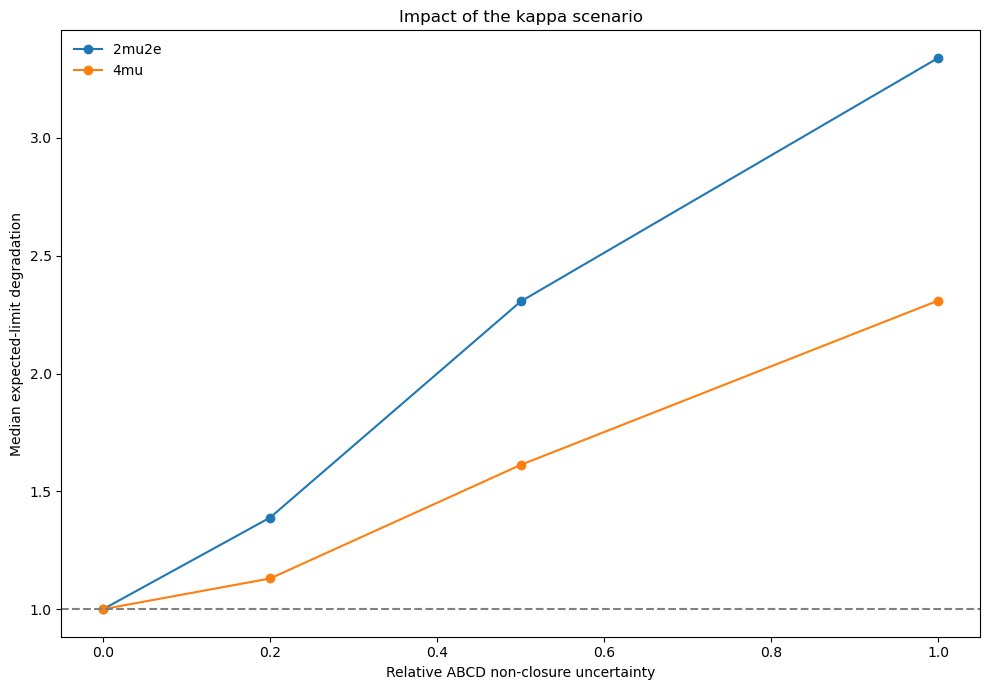

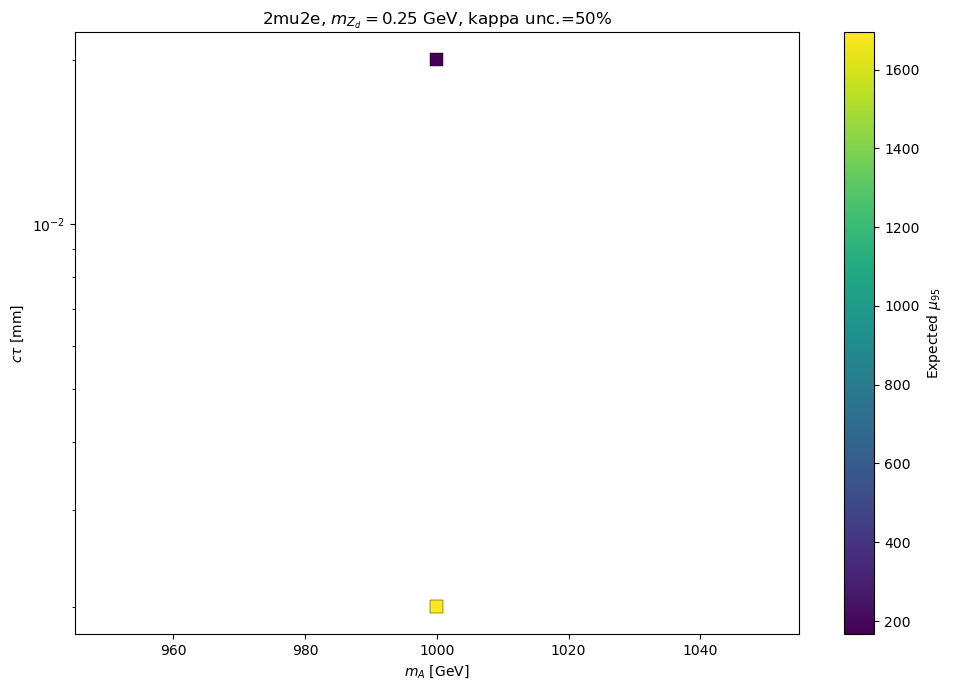

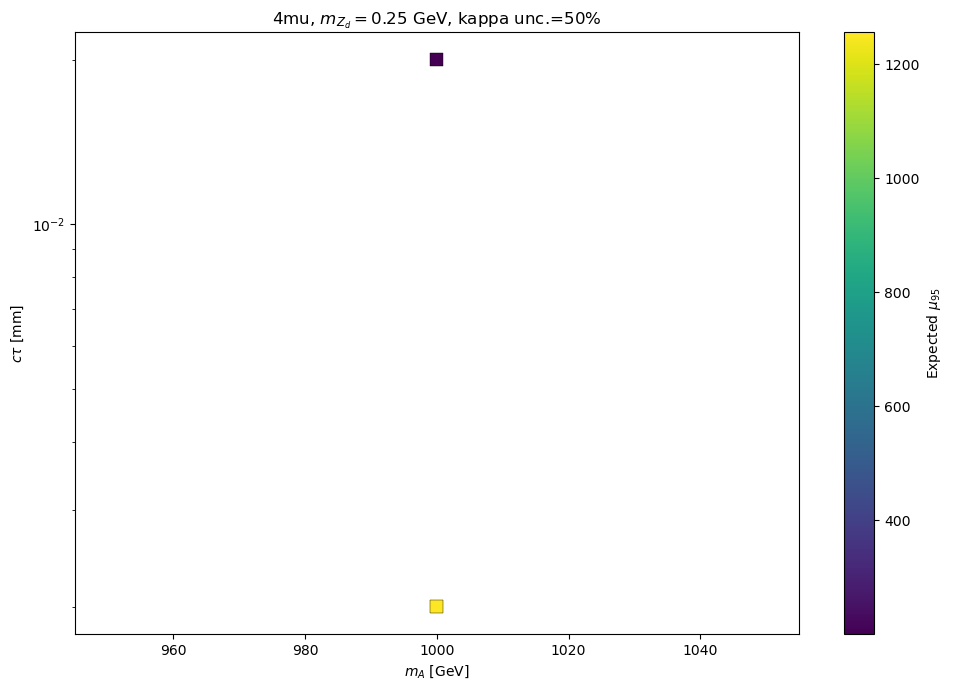

In [9]:
if not limit_table.empty:
    baseline = limit_table[limit_table.kappa_relative_uncertainty == 0.0][
        ["signal", "exp_median"]
    ].rename(columns={"exp_median": "baseline_exp_median"})
    limit_table = limit_table.merge(baseline, on="signal", how="left")
    limit_table["limit_degradation"] = (
        limit_table.exp_median / limit_table.baseline_exp_median
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    for topology, frame in limit_table.groupby("topology"):
        summary = frame.groupby("kappa_relative_uncertainty").limit_degradation.median()
        ax.plot(summary.index, summary.values, marker="o", label=topology)
    ax.axhline(1.0, color="gray", linestyle="--")
    ax.set(
        xlabel="Relative ABCD non-closure uncertainty",
        ylabel="Median expected-limit degradation",
        title="Impact of the kappa scenario",
    )
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()


def plot_limit_map(frame, value="exp_median"):
    finite = frame[np.isfinite(frame[value]) & (frame.ctau_mm > 0)].copy()
    if finite.empty:
        return None
    fig, ax = plt.subplots(figsize=(10, 7))
    points = ax.scatter(
        finite.mA_GeV, finite.ctau_mm, c=finite[value], s=90,
        marker="s", cmap="viridis", edgecolor="black", linewidth=0.3,
    )
    ax.set_yscale("log")
    ax.set(
        xlabel=r"$m_A$ [GeV]", ylabel=r"$c\tau$ [mm]",
        title=(f"{finite.topology.iloc[0]}, $m_{{Z_d}}={finite.mZd_GeV.iloc[0]:g}$ GeV, "
               f"kappa unc.={finite.kappa_relative_uncertainty.iloc[0]:.0%}"),
    )
    fig.colorbar(points, ax=ax, label=r"Expected $\mu_{95}$")
    fig.tight_layout()
    return fig, ax


if not limit_table.empty:
    nominal = limit_table[limit_table.kappa_relative_uncertainty == 0.5]
    for (_, _), frame in nominal.groupby(["topology", "mZd_GeV"]):
        plot_limit_map(frame)
        plt.show()
        plt.close()


## 8. Export reproducible tables and a representative workspace

The output directory contains no SR Data A. Workspace JSON export is limited to a representative point to avoid creating hundreds of files during development.

In [10]:
RESULT_DIR.mkdir(parents=True, exist_ok=True)
sideband_table.to_csv(RESULT_DIR / "abcd_data_sidebands.csv", index=False)
signal_input_table.to_csv(RESULT_DIR / "signal_abcd_inputs.csv", index=False)
limit_table.to_csv(RESULT_DIR / "expected_mu_limits.csv", index=False)
failure_table.to_csv(RESULT_DIR / "expected_limit_failures.csv", index=False)

if signal_inputs:
    representative = next(iter(signal_inputs))
    inputs = signal_inputs[representative]
    workspace = build_workspace(
        data_sidebands[inputs["parameters"]["topology"]],
        inputs["regions"],
        kappa_relative_uncertainty=0.5,
    )
    with open(RESULT_DIR / "representative_workspace.json", "w") as output:
        json.dump(dict(workspace), output, indent=2)

print("Wrote:")
for path in sorted(RESULT_DIR.iterdir()):
    print(" -", path)
print("Expected-only ABCD limit machinery complete; SR Data A remains blinded.")


Wrote:
 - /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/expected_limit_outputs/.ipynb_checkpoints
 - /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/expected_limit_outputs/abcd_background_models.csv
 - /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/expected_limit_outputs/abcd_data_sidebands.csv
 - /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/expected_limit_outputs/expected_limit_failures.csv
 - /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/expected_limit_outputs/expected_mu_limits.csv
 - /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/expected_limit_outputs/mass_scan_signal_inputs.csv
 - /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/expected_limit_outputs/representative_workspace.json
 - /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/expected_limit_outputs/signal_abcd_inputs.csv
Expected-only ABCD limit machinery complete; SR Data A remains blinded.


## 9. Data-CR and MC-only mass-scan inputs

Prepare the two background models and the complete $3\times5$ $(m_{Z_d},L_{xy})$ scan. SR Data A is never read.


In [11]:
from sidm.tools.utilities import lab_ctau

BKG_DIR = BASE / 'test_ABCD_bkg_full_merge_v1'
BACKGROUND_MODELS = ('data_cr', 'mc_only')
NOMINAL_KAPPA_RELATIVE_UNCERTAINTY = 0.50
TARGET_MASSES_GEV = (200.0, 500.0, 800.0, 1000.0)
TARGET_MZD_GEV = (0.25, 1.2, 5.0)
TARGET_LXY_CM = (0.3, 3.0, 30.0, 150.0, 300.0)

mc_sidebands = {}
for topology, config in CHANNEL_CONFIGS.items():
    pieces = [select_channel(load_sample(path, config['hist']), config['channel'])
              for path in sorted(BKG_DIR.glob('*.coffea'))]
    total = add_histograms(pieces)
    mc_sidebands[topology] = region_stats(total, config['cuts'], regions=('B','C','D'))
    del pieces, total
    gc.collect()

background_sidebands = {'data_cr': data_sidebands, 'mc_only': mc_sidebands}
background_rows = []
for model, topology_map in background_sidebands.items():
    for topology, stats in topology_map.items():
        row = {'background_model': model, 'topology': topology}
        for region in ('B','C','D'):
            row[region] = stats[region]['yield']
            row[f'{region}_variance'] = stats[region]['variance']
        row['A_raw_prediction'] = row['B']*row['C']/row['D']
        background_rows.append(row)
background_model_table = pd.DataFrame(background_rows)

mass_scan_signal_table = signal_input_table.copy()
mass_scan_signal_table['lxy_cm'] = [lab_ctau(int(ma), float(mzd), float(ctau))
    for ma, mzd, ctau in mass_scan_signal_table[['mA_GeV','mZd_GeV','ctau_mm']].itertuples(index=False, name=None)]
mass_scan_signal_table = mass_scan_signal_table[
    mass_scan_signal_table.mA_GeV.isin(TARGET_MASSES_GEV) &
    mass_scan_signal_table.mZd_GeV.isin(TARGET_MZD_GEV) &
    mass_scan_signal_table.lxy_cm.isin(TARGET_LXY_CM)
].sort_values(['mZd_GeV','lxy_cm','mA_GeV','topology']).reset_index(drop=True)
expected_rows = len(TARGET_MASSES_GEV)*len(TARGET_MZD_GEV)*len(TARGET_LXY_CM)*len(CHANNEL_CONFIGS)
assert len(mass_scan_signal_table) == expected_rows
assert np.all(background_model_table[['B','C','D']].to_numpy() > 0)
display(background_model_table)
display(mass_scan_signal_table[['signal','topology','mA_GeV','mZd_GeV','ctau_mm','lxy_cm']].head(12))
print('Plot configurations per background model:', len(TARGET_MZD_GEV)*len(TARGET_LXY_CM))


,background_model,topology,B,B_variance,C,C_variance,D,D_variance,A_raw_prediction
0,data_cr,2mu2e,134.000000,134.000000,167.000000,167.000000,305.000000,305.000000,73.370492
1,data_cr,4mu,18.000000,18.000000,177.000000,177.000000,36.000000,36.000000,88.500000
2,mc_only,2mu2e,129.012827,5216.720674,30.956559,183.843276,366.355785,24489.133121,10.901406
3,mc_only,4mu,0.746976,0.435706,1.806314,0.892352,32.116788,123.655166,0.042011


,signal,topology,mA_GeV,mZd_GeV,ctau_mm,lxy_cm
0,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.0100,0.3
1,4Mu_200GeV_0p25GeV_0p01mm,4mu,200.0,0.25,0.0100,0.3
2,2Mu2E_500GeV_0p25GeV_0p004mm,2mu2e,500.0,0.25,0.0040,0.3
3,4Mu_500GeV_0p25GeV_0p004mm,4mu,500.0,0.25,0.0040,0.3
4,2Mu2E_800GeV_0p25GeV_0p0025mm,2mu2e,800.0,0.25,0.0025,0.3
5,4Mu_800GeV_0p25GeV_0p0025mm,4mu,800.0,0.25,0.0025,0.3
6,2Mu2E_1000GeV_0p25GeV_0p002mm,2mu2e,1000.0,0.25,0.0020,0.3
7,4Mu_1000GeV_0p25GeV_0p002mm,4mu,1000.0,0.25,0.0020,0.3
8,2Mu2E_200GeV_0p25GeV_0p1mm,2mu2e,200.0,0.25,0.1000,3.0
9,4Mu_200GeV_0p25GeV_0p1mm,4mu,200.0,0.25,0.1000,3.0


Plot configurations per background model: 15


In [12]:
RESULT_DIR.mkdir(parents=True, exist_ok=True)
background_model_table.to_csv(RESULT_DIR / 'abcd_background_models.csv', index=False)
mass_scan_signal_table.to_csv(RESULT_DIR / 'mass_scan_signal_inputs.csv', index=False)
print('Wrote dual-background and 3x5 mass-scan inputs; SR Data A remains blinded.')


Wrote dual-background and 3x5 mass-scan inputs; SR Data A remains blinded.
